In [1]:
import numpy as np
import pandas as pd
from sklearn import svm
from sklearn import model_selection
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, classification_report,confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
df_test=pd.read_csv("../../../features/test_features.csv", sep=",")
df_validation=pd.read_csv("../../../features/validation_features.csv", sep=",")
df_train=pd.read_csv("../../../features/train_features.csv", sep=",")

In [3]:
X_train = df_train.drop(['filename','classe'], axis = 1)
y_train = df_train['classe']

X_test = df_test.drop(['filename','classe'], axis = 1)
y_test = df_test['classe']

X_val=df_validation.drop(['filename','classe'], axis = 1)
y_val=df_validation['classe']

In [4]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
X_val_scaled=scaler.transform(X_val)


In [5]:
parametres = {'C':[0.1,1,10], 'kernel':['rbf','linear', 'poly'], 'gamma':[0.001, 0.1, 0.5]}
clf = svm.SVC(class_weight='balanced')
grid_clf = model_selection.GridSearchCV(estimator=clf, param_grid=parametres)
grille = grid_clf.fit(X_train_scaled,y_train)

print(pd.DataFrame.from_dict(grille.cv_results_).loc[:,['params', 'mean_test_score']]) 





                                            params  mean_test_score
0      {'C': 0.1, 'gamma': 0.001, 'kernel': 'rbf'}         0.467603
1   {'C': 0.1, 'gamma': 0.001, 'kernel': 'linear'}         0.491961
2     {'C': 0.1, 'gamma': 0.001, 'kernel': 'poly'}         0.317524
3        {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}         0.523339
4     {'C': 0.1, 'gamma': 0.1, 'kernel': 'linear'}         0.491961
5       {'C': 0.1, 'gamma': 0.1, 'kernel': 'poly'}         0.520399
6        {'C': 0.1, 'gamma': 0.5, 'kernel': 'rbf'}         0.522139
7     {'C': 0.1, 'gamma': 0.5, 'kernel': 'linear'}         0.491961
8       {'C': 0.1, 'gamma': 0.5, 'kernel': 'poly'}         0.488239
9        {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}         0.483442
10    {'C': 1, 'gamma': 0.001, 'kernel': 'linear'}         0.492141
11      {'C': 1, 'gamma': 0.001, 'kernel': 'poly'}         0.327149
12         {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}         0.527899
13      {'C': 1, 'gamma': 0.1, 'kernel': 'linear

In [6]:
print(grid_clf.best_params_)

{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [7]:
def evaluer(model, X, y, titre):
    """Affiche accuracy, classification_report et matrice de confusion."""
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)

    print(f"===== {titre} =====")
    print(f"Accuracy : {acc:.4f}\n")
    print(classification_report(y, y_pred, zero_division=0))

    cm = confusion_matrix(y, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, square=True, fmt=".2f", cmap="mako")

    ax.set_title(f"Matrice de confusion — {titre}")
    plt.tight_layout()
    plt.show()
    return acc

===== SVM — Validation =====
Accuracy : 0.5295

                 precision    recall  f1-score   support

          COVID       0.25      0.17      0.20       338
   Lung_Opacity       0.55      0.56      0.55       598
         Normal       0.70      0.61      0.65      1013
Viral Pneumonia       0.26      0.71      0.38       134

       accuracy                           0.53      2083
      macro avg       0.44      0.51      0.45      2083
   weighted avg       0.55      0.53      0.53      2083



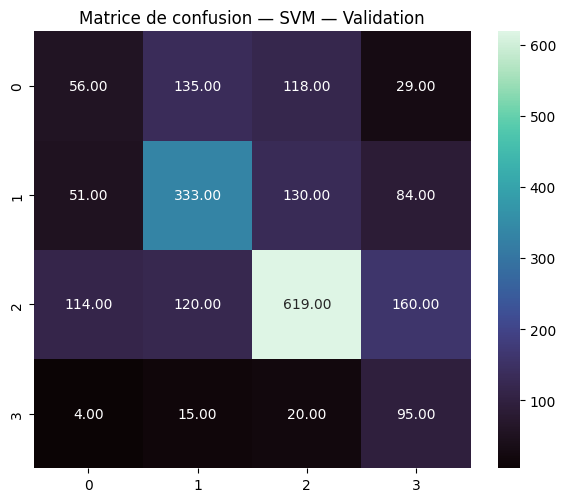

===== SVM — Test =====
Accuracy : 0.5446

                 precision    recall  f1-score   support

          COVID       0.34      0.23      0.28       337
   Lung_Opacity       0.56      0.57      0.57       599
         Normal       0.72      0.60      0.65      1014
Viral Pneumonia       0.27      0.77      0.40       134

       accuracy                           0.54      2084
      macro avg       0.47      0.54      0.47      2084
   weighted avg       0.58      0.54      0.55      2084



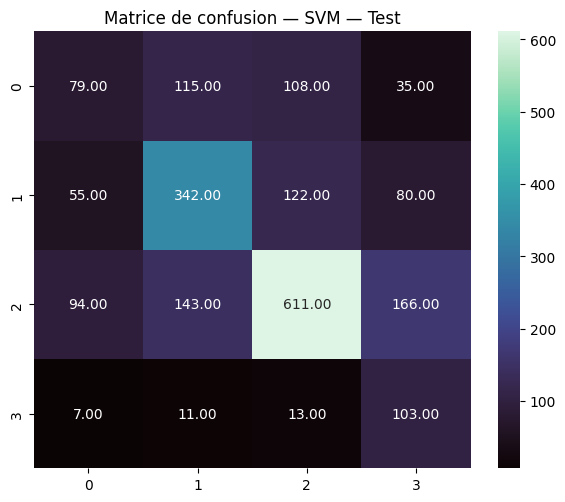

In [8]:

acc_val  = evaluer(grid_clf, X_val_scaled,  y_val,  "SVM — Validation")
acc_test = evaluer(grid_clf, X_test_scaled, y_test, "SVM — Test")